## PHASE 1: IMPORTING DATA

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv(r"C:\Users\kanis\Github Python Project\github_illusion_dirty.csv")

## PHASE 2:DATA EXPLORTAION

In [185]:

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())
print(df.columns)
print(df.info())

print(df.isnull().sum())
print(df.duplicated().sum())
print('username col dupliactes : ',df.duplicated(subset=['username']).sum())

numeric_cols=['total_repos','total_commits','avg_commit_hour','stars',
              'forks','star_fork_ratio','followers','following',
              'readme_score','has_bio','has_profile_pic',
              'suspicion_score','profile_age_days']

for col in numeric_cols:
    print(col,'min:',df[col].min(),'max:',df[col].max())

print(df['star_fork_ratio'].describe())
print('null count in star_fork_ratio col:',(df['star_fork_ratio']==np.inf).sum())

print(df['commit_streak'].dtype)
print(df['commit_streak'].unique()[:10])
print(df['commit_streak'].astype(str).str.contains('days').sum())

print(df['bot_like_score'].unique())

print(df['language'].nunique())
print(df['language'].value_counts(dropna=False).head(15))

print(df['country'].nunique())
print(df['country'].value_counts(dropna=False))

print(df['account_created'].head(10).tolist())
print(df['account_created'][df['account_created'].isin(['N/A','never','unknown','',' '])].value_counts())

print(df['last_commit_date'].head(10).tolist())
print(df['last_commit_date'][df['last_commit_date'].isin(['N/A','never','unknown','',' '])].value_counts())

print(df['_profile_type'].value_counts())

(105000, 21)
username             object
account_created      object
last_commit_date     object
total_repos         float64
total_commits       float64
commit_streak        object
avg_commit_hour     float64
stars               float64
forks               float64
star_fork_ratio     float64
followers           float64
following           float64
readme_score        float64
language             object
country              object
has_bio             float64
has_profile_pic     float64
bot_like_score       object
suspicion_score     float64
profile_age_days    float64
_profile_type         int64
dtype: object
         username account_created   last_commit_date  total_repos  \
0  wblackburn1825      08-17-2021   October 11, 2020         47.0   
1  reneecampos410     25 May 2012  November 02, 2022          3.0   
2    paullutz4507      07-21-2022         02-03-2024         91.0   
3   maureen114013      11/02/2009         16/12/2023        230.0   
4      dayala3658      23/11/2015       

### PHASE 3 : DATA CLEANING

In [186]:
df.shape

(105000, 21)


### Dropping Duplicate Rows


In [187]:
df.drop_duplicates(subset=['username'],keep='first',inplace=True)
df.shape

(101807, 21)

### Fix:account_created

In [188]:
df['account_created']=pd.to_datetime(df['account_created'],format='mixed',errors='coerce')
df['account_created'].head()
df[df['account_created']>pd.Timestamp.now()]

,username,account_created,last_commit_date,total_repos,total_commits,commit_streak,avg_commit_hour,stars,forks,star_fork_ratio,...,following,readme_score,language,country,has_bio,has_profile_pic,bot_like_score,suspicion_score,profile_age_days,_profile_type



### Fix:last_commit_date

In [189]:
df['last_commit_date']=df['last_commit_date'].replace(['N/A','never','unknown','',' '],np.nan)
df['last_commit_date']=pd.to_datetime(df['last_commit_date'],format='mixed',errors='coerce')


### Fix:commit_streak

In [190]:
df['commit_streak']=df['commit_streak'].astype('str').str.replace(' days','')
df['commit_streak']=df['commit_streak'].astype('float64')
df.dtypes

username                    object
account_created     datetime64[ns]
last_commit_date    datetime64[ns]
total_repos                float64
total_commits              float64
commit_streak              float64
avg_commit_hour            float64
stars                      float64
forks                      float64
star_fork_ratio            float64
followers                  float64
following                  float64
readme_score               float64
language                    object
country                     object
has_bio                    float64
has_profile_pic            float64
bot_like_score              object
suspicion_score            float64
profile_age_days           float64
_profile_type                int64
dtype: object


### Fix:language

In [191]:
df['language']=df['language'].fillna('unknown').astype('str').str.lower().str.strip()
df['language']=df['language'].replace(['none','n/a','','nan'],'unknown')
df['language']=df['language'].str.title()
df['language']=df['language'].astype('category')


### Fix:country


In [192]:
country_map={
    'in': 'India', 'ind': 'India', 'india': 'India',
    'us': 'United States', 'usa': 'United States', 'united states': 'United States',
    'cn': 'China', 'china': 'China',
    'de': 'Germany', 'germany': 'Germany',
    'uk': 'United Kingdom', 'united kingdom': 'United Kingdom',
    'br': 'Brazil', 'brazil': 'Brazil',
    'ca': 'Canada', 'canada': 'Canada',
    'fr': 'France', 'france': 'France',
    'ru': 'Russia', 'russia': 'Russia',
    'jp': 'Japan', 'japan': 'Japan',
    'au': 'Australia', 'australia': 'Australia',
}
df['country']=df['country'].fillna('Unknown').str.lower().str.strip()
df['country']=df['country'].map(country_map).fillna('Unknown')
df['country']=df['country'].str.title().astype('category')

### Fix:star_fork_ratio 

In [193]:
cap=df['star_fork_ratio'].replace([np.inf,-np.inf],np.nan).quantile(0.99)
df['star_fork_ratio']=(df['star_fork_ratio']).replace([np.inf,-np.inf],cap)
df['star_fork_ratio']=df['star_fork_ratio'].fillna(0)

### Fix:avg_commit_hour

In [194]:

df.loc[(df['avg_commit_hour']<0)|(df['avg_commit_hour']>23),'avg_commit_hour']=np.nan 
median=df['avg_commit_hour'].median()
df['avg_commit_hour']=df['avg_commit_hour'].fillna(median)


### Fix:bot_like_score

In [195]:

df['bot_like_score']=df['bot_like_score'].astype('str').str.lower().str.strip()
df['bot_like_score']=df['bot_like_score'].replace({'1':'1','yes':'1','true':'1','no':'0','false':'0','0':'0','maybe':np.nan,'nan':np.nan})
df['bot_like_score']=pd.to_numeric(df['bot_like_score'],errors='coerce').astype('Int64')



### Fix:profile_age_days

In [196]:

df.loc[(df['profile_age_days']<1)|(df['profile_age_days']>6000),'profile_age_days']=np.nan
df['profile_age_days']=df['profile_age_days'].fillna(df['profile_age_days'].median())




### Fix:stars,forks,has_bio,has_profile_pic

In [197]:

for col in ['stars','forks','has_bio','has_profile_pic']:
    df[col]=df[col].fillna(0).astype(int)

### Fix:followers,following,readme_score,total_repos,total_commits,commit_streak


In [198]:
for col in ['followers','following','readme_score','total_repos','total_commits','commit_streak']:
    df[col]=df[col].fillna(df[col].median())

### Convert commit_streak into int 

In [199]:
df['commit_streak']=df['commit_streak'].astype('int')

## Feature Engineering

In [200]:
df['account_age_years']=(pd.Timestamp.now()-df['account_created']).dt.days/365.25

df['commit_frequency']=(df['total_commits']/df['account_age_years']).replace([np.inf,-np.inf],np.nan)
df['commit_frequency']=df['commit_frequency'].fillna(0)

df['follow_ratio']=(df['followers']/df['following']).replace([np.inf,-np.inf],np.nan)
df['follow_ratio']=df['follow_ratio'].fillna(0)

df['follow_ratio'].isin([np.inf,-np.inf]).sum()

df['repo_commit_ratio']=(df['total_repos']/df['total_commits']).replace([np.inf,-np.inf],np.nan)
df['repo_commit_ratio']=df['repo_commit_ratio'].fillna(0)

df['suspicious_hrs']=df['avg_commit_hour'].apply(lambda j:1 if(j<=4 or j>=23) else 0)


### Compute Suspicion Score

In [201]:
def compute_suspicion(row):
    score=0
    if row['star_fork_ratio']>50:
        score+=0.25
    if row['follow_ratio']<0.05:
        score+=0.20
    if row['readme_score']<3:
        score+=0.20
    if row['suspicious_hrs']==1:
        score+=0.15
    if row['commit_streak'] in [100,200,300,365,500]:
        score+=0.10
    if row['has_bio']==0:
        score+=0.05
    if row['has_profile_pic']==0:
        score+=0.05
    return round(min(score,1.0),3)



mask=df['suspicion_score'].isnull()
df.loc[mask,'suspicion_score']=df[mask].apply(compute_suspicion,axis=1)

df['is_suspicious']=df['suspicion_score'].apply(lambda x:1 if x>=0.5 else 0)
print(df['is_suspicious'].value_counts())

is_suspicious
0    67074
1    34733
Name: count, dtype: int64



## Export Clean Data

In [202]:
df.to_csv(r"C:\Users\kanis\Github Python Project\github_illusion_clean.csv",index=False)


## PHASE 4 - DEEP ANALYSIS


In [203]:
data=pd.read_csv(r"C:\Users\kanis\Github Python Project\github_illusion_clean.csv")
data.head()


,username,account_created,last_commit_date,total_repos,total_commits,commit_streak,avg_commit_hour,stars,forks,star_fork_ratio,...,bot_like_score,suspicion_score,profile_age_days,_profile_type,account_age_years,commit_frequency,follow_ratio,repo_commit_ratio,suspicious_hrs,is_suspicious
0,wblackburn1825,2021-08-17,2020-10-11,47.0,1861.0,304,18.0,237,125,1.896,...,0.0,0.000,2391.0,0,4.835044,384.898216,14.393162,0.025255,0,0
1,reneecampos410,2012-05-25,2022-11-02,3.0,1809.0,219,15.0,467,41,11.390,...,0.0,0.100,258.0,2,14.064339,128.623175,0.568966,0.001658,0,0
2,paullutz4507,2022-07-21,2024-02-03,91.0,12345.0,100,0.0,263,0,572.290,...,1.0,0.614,1187.0,1,3.909651,3157.570903,0.001608,0.007371,1,1
3,maureen114013,2009-11-02,2023-12-16,230.0,1834.0,200,1.0,435,3,145.000,...,1.0,0.783,1832.0,1,16.624230,110.320899,0.005608,0.125409,1,1
4,dayala3658,2015-11-23,2022-11-18,76.0,760.0,145,22.0,85,34,2.500,...,0.0,0.000,1780.0,0,10.568104,71.914508,2.258667,0.100000,0,0


In [204]:
data.dtypes

username              object
account_created       object
last_commit_date      object
total_repos          float64
total_commits        float64
commit_streak          int64
avg_commit_hour      float64
stars                  int64
forks                  int64
star_fork_ratio      float64
followers            float64
following            float64
readme_score         float64
language              object
country               object
has_bio                int64
has_profile_pic        int64
bot_like_score       float64
suspicion_score      float64
profile_age_days     float64
_profile_type          int64
account_age_years    float64
commit_frequency     float64
follow_ratio         float64
repo_commit_ratio    float64
suspicious_hrs         int64
is_suspicious          int64
dtype: object

## Q1.How many profiles are suspicios vs genuine?


In [205]:
data['is_suspicious'].value_counts()

is_suspicious
0    67074
1    34733
Name: count, dtype: int64

#### Out of 101807 profiles in the dataset,67074 were flagged as genuine and 34733 were flagged as suspicious 

## Q2.What percentage of all profiles are flagged suspicious?

In [206]:
suspicious_pct=data['is_suspicious'].mean()*100
print(f"{suspicious_pct:.2f}% of profiles are suspicious")

34.12% of profiles are suspicious


#### 34.12% of all profiles in the dataset show suspicious,bot-like activity patterns

## Q3.what is the average README score overall and split by suspicious vs genuine?

In [207]:
data['readme_score'].mean()
data.groupby('is_suspicious')['readme_score'].mean()

is_suspicious
0    6.287654
1    2.282463
Name: readme_score, dtype: float64


#### On average,genuine profiles score 6.3/10 on readme quality,while suspicious profiles score only 2.3/10 - a gap of 4 points

## Q4.What are the top 10 profiles by stars?

In [208]:
data.sort_values('stars',ascending=False)[['username','stars','forks','is_suspicious']].head(10)

,username,stars,forks,is_suspicious
17133,brucemills6998,7559,83,1
92108,davidvillegas6881,7236,8,1
89895,nicole654954,7067,127,1
40178,lmurphy414,6991,109,1
16412,ucolon9283,6917,6,1
75066,anthonyjennifer857,6866,9,1
52152,susancooper6614,6600,14,1
9430,connienguyen2760,6577,42,1
74436,twhitney8626,6314,95,1
3697,nicole277956,6236,118,1


#### Among the top 10 most-starred profiles ,10 out of 10 are flagged as suspicious,showing that raw star count alone is a poor signal of quality.

## Q5.How many profiles have stars>1000 but forks<10?

In [209]:
fake_popularity=data[(data['stars']>1000)&(data['forks']<10)]
len(fake_popularity)

2668

#### 2668 profiles(2.6% of the adtaset) have over 1000 stars but fewer than 10 forks - a textbook sign of inflated,unearned popularity

## Q6.Of those high-star/low-fork profiles,what % are flagged suspicious?

In [210]:
fake_popularity['is_suspicious'].mean()*100

np.float64(99.66266866566717)


#### Of these high-star/low-fork profiles,99.6% are independently flagged as suspicious by the scoring system - confirming this pattern is a genuine fake-popularity signal,not a coincidence

## Q7.What percentage of profiles commit during 'suspicious hours'(suspicious_hrs==1)?


In [211]:
data.groupby('is_suspicious')['suspicious_hrs'].mean()*100

is_suspicious
0     0.004473
1    66.043820
Name: suspicious_hrs, dtype: float64

#### Within suspicious profiles this rises to 66.04% vs only 0.0044% for genuine ones -~1036x difference

## Q8.What is the average follow_ratio for suspicious vs genuine profiles?

In [212]:
data.groupby('is_suspicious')['follow_ratio'].mean()

is_suspicious
0    13.439566
1     2.364464
Name: follow_ratio, dtype: float64

#### Suspicious profiles have average follow ratio of 2.36,compared to 13.43 for genuine profiles - meaning suspicious accounts get followed back 5.68 times less,relative to how many accounts they follow

## Q9.How many profiles have a follow_ratio below 0.05(extreme mass-follow behavior)?

In [213]:
mass_followers=data[data['follow_ratio']<0.05]
print(len(mass_followers))

mass_followers['is_suspicious'].mean()*100

28240


np.float64(97.98512747875354)

#### 28240 profiles(27.7% of the dataset) follow far more accounts than follow them back.Of these,97% are already flagged as suspicious

## Q10.Which country has the most profiles in the dataset?

In [214]:
data['country'].value_counts().head(10)

country
United States     12583
Unknown           10230
India             10111
Brazil             7785
Japan              7684
Canada             7675
United Kingdom     7660
China              7650
Germany            7625
Australia          7622
Name: count, dtype: int64

#### United States has the most profiles in the dataset at 12583,followed by India with 10111

## Q11.Which country has the highest average suspicion_score?

In [215]:
data.groupby('country')['suspicion_score'].mean().sort_values(ascending=False).head(10)

country
Australia         0.383112
United Kingdom    0.379455
India             0.378770
United States     0.376869
Russia            0.376823
Canada            0.376727
Brazil            0.376485
China             0.376349
Germany           0.375326
France            0.374881
Name: suspicion_score, dtype: float64

#### Australia has the highest average suspicion score at 0.3811

## Q12.Which programming language has the highest average stars?

In [216]:
data.groupby('language')['stars'].mean().sort_values(ascending=False).head(10)

language
Typescript    344.257863
Rust          343.630009
R             343.177061
Kotlin        342.798266
Go            338.114938
Unknown       337.131697
Php           336.742934
Shell         333.479371
Javascript    333.063186
C++           332.542741
Name: stars, dtype: float64

#### TypeScript developers have the highest average star count at 344.2

## Q13.Which language has the highest percentage of suspicious profiles?(Only consider languages with atleast 500 profiles)

In [217]:
temp=data['language'].value_counts()
valid=temp[temp>=500].index
check=data[data['language'].isin(valid)]
check.groupby('language')['is_suspicious'].mean().sort_values(ascending=False)*100

language
Rust          34.803294
Php           34.783138
Shell         34.589882
Unknown       34.390881
Swift         34.341014
Typescript    34.292352
R             34.121864
Go            34.074871
Javascript    34.040757
Kotlin        33.917284
C++           33.858706
Java          33.672357
Python        33.277632
Ruby          33.203560
Name: is_suspicious, dtype: float64

#### Among languages with 500+ profiles ,Rust has the highest suspicious rate at 34.8%.

## Q14.Cross-tab:Account age bucket vs Suspicious status

In [218]:
data['age_bucket']=pd.cut(
    data['account_age_years'],
    bins=[0,1,2,4,6,8,20],
    labels=['< 1 yr','1-2 yr','2-4 yr','4-6 yr','6-8 yr','8 yr+']
)
pd.crosstab(data['age_bucket'],data['is_suspicious'],normalize='index')*100

is_suspicious,0,1
age_bucket,,
2-4 yr,66.077056,33.922944
4-6 yr,65.719757,34.280243
6-8 yr,65.188245,34.811755
8 yr+,66.019607,33.980393


#### Suspicious activity is fairly consistent across account age groups,ranging from 33.9% to 34.7% ,suggesting that account age alone is not a strong predictor of suspicious behavior

## Q15.For each suspicion tier(Clean/Borderline/Likely Bot/Comfirmed Bot),what's the average README score and average stars?

In [219]:
data['suspicion_tier']=pd.cut(
    data['suspicion_score'],
    bins=[0,0.25,0.50,0.75,1.01],
    labels=['Clean','Borderline','Likely Bot','Confirmed Bot']
)
data.groupby('suspicion_tier')[['readme_score','stars','forks','follow_ratio']].mean()

,readme_score,stars,forks,follow_ratio
suspicion_tier,,,,
Clean,6.601305,135.212529,38.800867,13.845114
Borderline,5.606691,185.993705,33.382780,12.907155
Likely Bot,2.867482,573.176695,16.194253,5.334788
Confirmed Bot,1.816229,781.647001,7.188386,0.006509


#### Confirmed Bot tier profiles average 781.80 stars and a README score of 1.81/10,compared to 135.51 stars and 6.59/10 for 'Clean' tier profiles - almost a complete reversal in profile quality indicators

## Q16.Which 5 profiles look the MOST suspicious overall,and what do they have in common?

In [220]:
top_suspicious=data.sort_values('suspicion_score',ascending=False).head(5)
top_suspicious[['username','stars','forks','readme_score','follow_ratio','commit_streak','suspicious_hrs','suspicion_score']]

,username,stars,forks,readme_score,follow_ratio,commit_streak,suspicious_hrs,suspicion_score
101714,thomasluke2318,92,1,0.6,0.004981,100,1,1.0
16957,jason592391,592,2,2.2,0.003426,365,1,1.0
59288,davidmoore1408,575,0,0.6,0.003583,200,1,1.0
59281,coopervictoria1518,539,0,2.2,0.004817,365,1,1.0
59251,sramsey2934,566,1,2.0,0.001150,300,1,1.0


## Q17.For each language,show profile count,average suspicion score,and average README score - all in ONE table?

In [221]:
language_summary=data.groupby('language').agg(profile_count=('username','count'),avg_suspicion=('suspicion_score','mean'),avg_readme=('readme_score','mean')).sort_values('avg_suspicion',ascending=False)
language_summary

,profile_count,avg_suspicion,avg_readme
language,,,
Swift,5425,0.379652,4.903705
Shell,8144,0.379617,4.897151
Unknown,13774,0.379331,4.928372
Php,8208,0.378971,4.926693
Rust,5465,0.378603,4.874657
Javascript,8293,0.376516,4.941613
Kotlin,5537,0.376176,4.906357
Typescript,5596,0.375691,4.908113
C++,5393,0.374971,4.933914


#### Swift profiles have the highest average suspicion score(0.379) and one of the lowest average README scores (4.90/10),indicating a higher concentration of suspicious characteristics comapared to other languages communities

## Q18.Build a table:for the top 10 countries,how many profiles fall into each suspicion tier(Clean/Borderline/Likely Bot/Confirmed Bot)?

In [222]:
top_countries=data['country'].value_counts().head(10).index
filtered=data[data['country'].isin(top_countries)].copy()
filtered['country']=filtered['country'].astype('str')
table=pd.pivot_table(
    filtered,
    index='country',
    columns='suspicion_tier',
    values='username',
    aggfunc='count',
    fill_value=0
)
table

suspicion_tier,Clean,Borderline,Likely Bot,Confirmed Bot
country,,,,
Australia,2945,1491,1171,1498
Brazil,3147,1458,1122,1530
Canada,3105,1471,1139,1477
China,3092,1497,1143,1452
Germany,3059,1464,1095,1479
India,4033,1979,1498,1963
Japan,3067,1498,1186,1376
United Kingdom,3042,1505,1126,1498
United States,5091,2424,1920,2378


## Q19.Split profiles into Low/Medium/High commit frequency groups,then check the suspicious % in each group?           

In [223]:
low_cutoff=data['commit_frequency'].quantile(0.33)
high_cutoff=data['commit_frequency'].quantile(0.66)

def freq_bucket(x):
    if x<low_cutoff:
        return 'Low'
    elif x<high_cutoff:
        return 'Medium'
    else:
        return 'High'

data['freq_level']=data['commit_frequency'].apply(freq_bucket)
data.groupby('freq_level')['is_suspicious'].mean()*100

freq_level
High      71.333237
Low       12.052030
Medium    17.835457
Name: is_suspicious, dtype: float64

#### High-frequency committers are nearly 6x more likely to be classified as suspicious than low-frequency committers

## Q20.How many profiles trigger ALL FOUR major red flags at once - and does your suspicion_score system already catch them?              

In [224]:
red_flags=(
    (data['stars']>500) & 
    (data['follow_ratio']<0.05) & 
    (data['readme_score']<3) &
    (data['suspicious_hrs']==1)
)

extreme_profiles=data[red_flags]
print(f"Profiles matching all 4 red flags:{len(extreme_profiles)}")
print(f"% already flagged as suspicious:{extreme_profiles['is_suspicious'].mean()*100:.1f}%")

Profiles matching all 4 red flags:9124
% already flagged as suspicious:100.0%


#### 9,124 profiles trigger all four major red flags simulatneously,and 100.0% of them were already caught by the suspicion score system - validating that the scoring logic successfully identifies the most extreme suspicious profiles

## PHASE 4: VISUALIZATION

In [225]:
data.to_csv(r"C:\Users\kanis\Github Python Project\github_illusion_analysis.csv",index=False)

In [226]:
data2=pd.read_csv(r"C:\Users\kanis\Github Python Project\github_illusion_analysis.csv")
data2.head()
data2.columns

Index(['username', 'account_created', 'last_commit_date', 'total_repos',
       'total_commits', 'commit_streak', 'avg_commit_hour', 'stars', 'forks',
       'star_fork_ratio', 'followers', 'following', 'readme_score', 'language',
       'country', 'has_bio', 'has_profile_pic', 'bot_like_score',
       'suspicion_score', 'profile_age_days', '_profile_type',
       'account_age_years', 'commit_frequency', 'follow_ratio',
       'repo_commit_ratio', 'suspicious_hrs', 'is_suspicious', 'age_bucket',
       'suspicion_tier', 'freq_level'],
      dtype='object')

Genuine vs Suspicious

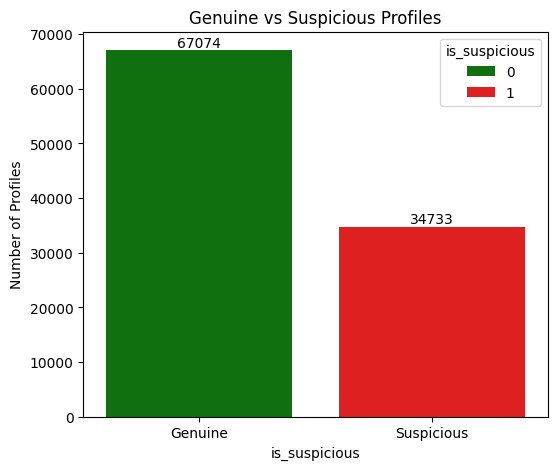

In [227]:
plt.figure(figsize=(6,5))
ax=sns.countplot(data=data2,x='is_suspicious',palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Genuine vs Suspicious Profiles')
plt.ylabel('Number of Profiles')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### Suspicion Tier Breakdown

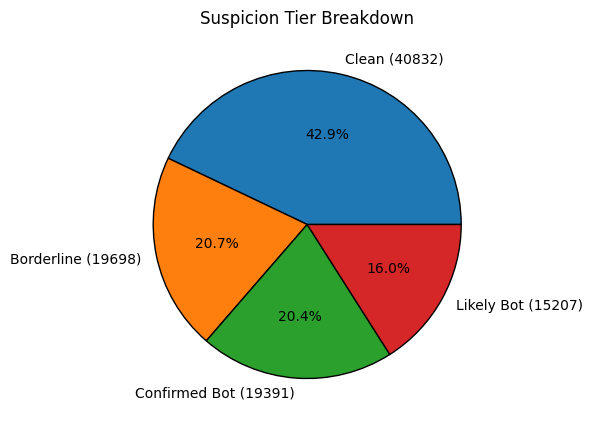

In [228]:
tier_counts=data2['suspicion_tier'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(tier_counts,
        labels=tier_counts.index.astype('str') + ' (' + tier_counts.astype(str) + ')',
        autopct='%1.1f%%',
        wedgeprops={'edgecolor':'black','linewidth':1})
plt.title('Suspicion Tier Breakdown')
plt.show()

### Average README Score

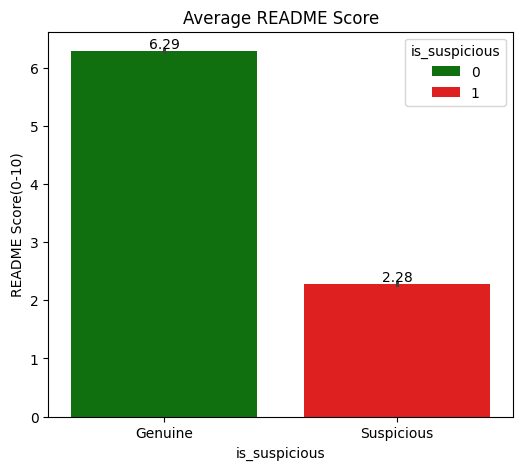

In [229]:
plt.figure(figsize=(6,5))
ax=sns.barplot(data=data2,x='is_suspicious',y='readme_score',palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Average README Score')
plt.ylabel('README Score(0-10)')

for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
plt.show()

### Stars vs Forks

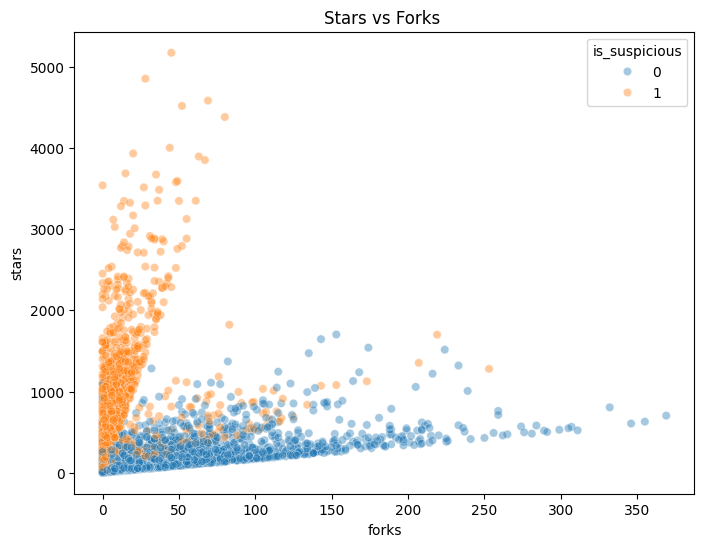

In [230]:
sample=data2.sample(5000,random_state=42)
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample,x='forks',y='stars',hue='is_suspicious',alpha=0.4)
plt.title('Stars vs Forks ')
plt.show()

### README Score Distribution

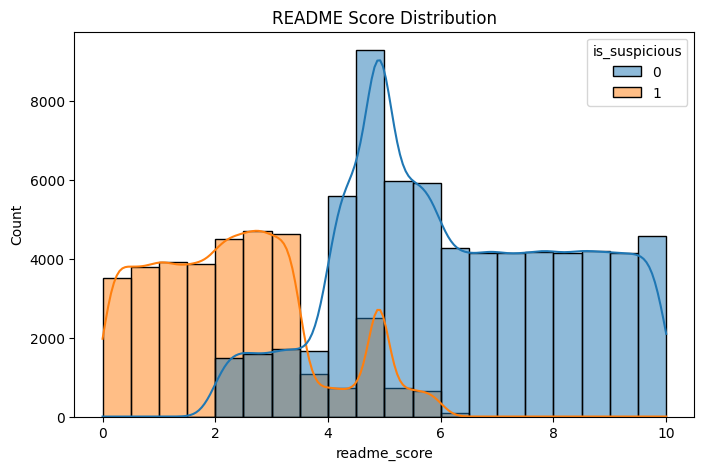

In [231]:
plt.figure(figsize=(8,5))
sns.histplot(data=data2,x='readme_score',hue='is_suspicious',kde=True,bins=20)
plt.title('README Score Distribution')
plt.show()

### README Score by Suspicion Tier

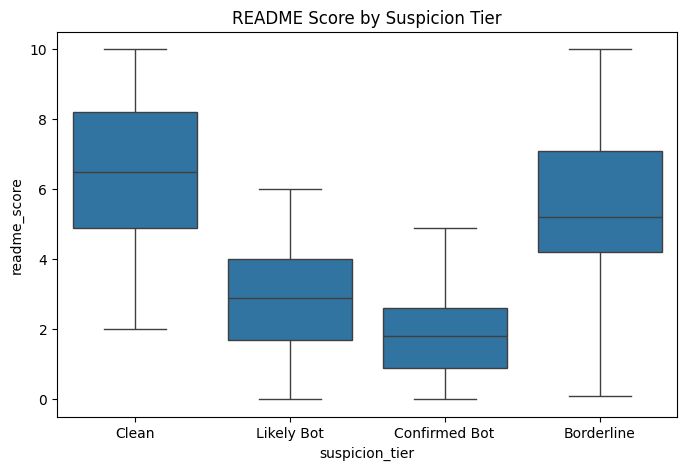

In [232]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data2,x='suspicion_tier',y='readme_score')
plt.title('README Score by Suspicion Tier')
plt.show()

### Commit Streak Distribution

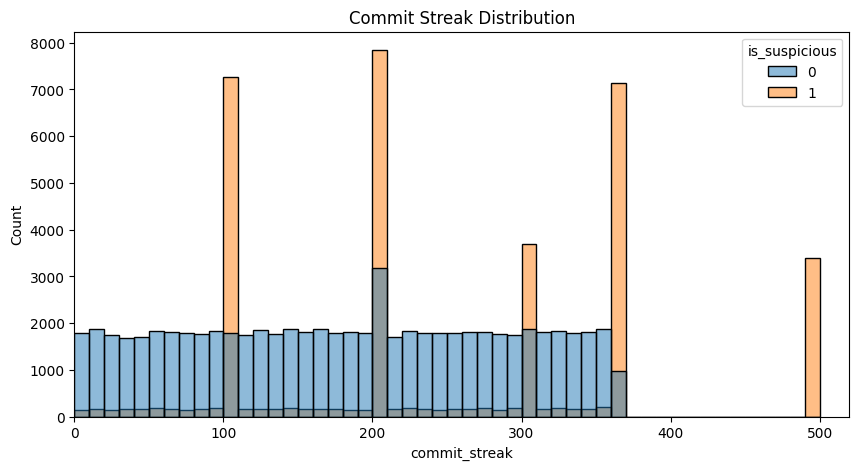

In [233]:
plt.figure(figsize=(10,5))
sns.histplot(data=data2,x='commit_streak',hue='is_suspicious',bins=50)
plt.xlim(0,520)
plt.title('Commit Streak Distribution')
plt.show()

### Average Follow Ratio

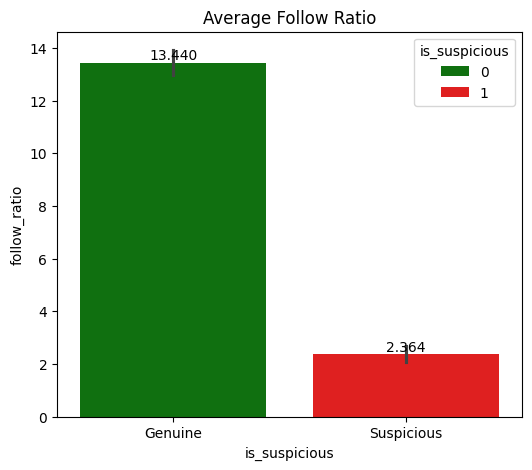

In [234]:
plt.figure(figsize=(6,5))
ax=sns.barplot(data=data2,x='is_suspicious',y='follow_ratio',palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Average Follow Ratio')
for container in ax.containers:
    ax.bar_label(container,fmt='%.3f')
plt.show()



### Followers vs Following

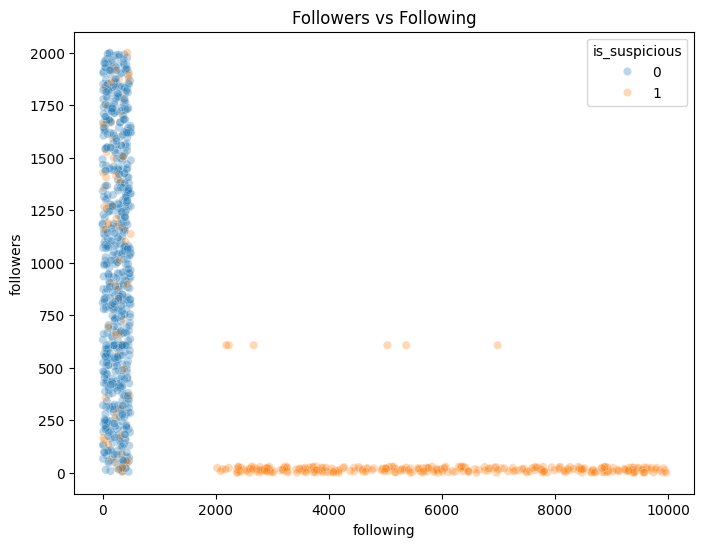

In [235]:
sample2=data2.sample(1000,random_state=7)
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample2,x='following',y='followers',hue='is_suspicious',alpha=0.3)
plt.title('Followers vs Following')
plt.show()

### Suspicion Rate by Language

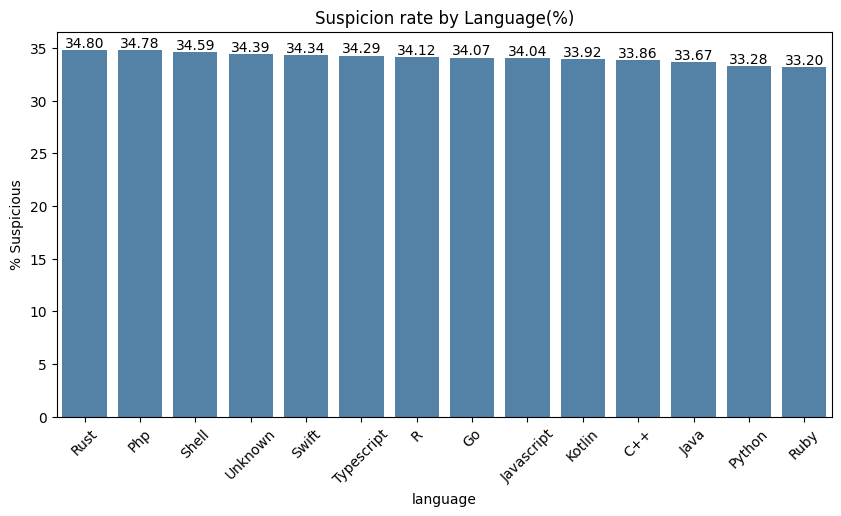

In [236]:
lang_counts=data2['language'].value_counts()
valid=lang_counts[lang_counts>=500].index
filtered=data2[data2['language'].isin(valid)]
lang_sus=filtered.groupby('language')['is_suspicious'].mean().sort_values(ascending=False)*100
plt.figure(figsize=(10,5))
ax=sns.barplot(x=lang_sus.index,y=lang_sus.values,color='steelblue')
plt.xticks(rotation=45)
plt.title('Suspicion rate by Language(%)')
plt.ylabel('% Suspicious')
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
plt.show()

### Top 10 Countries by Profile Count

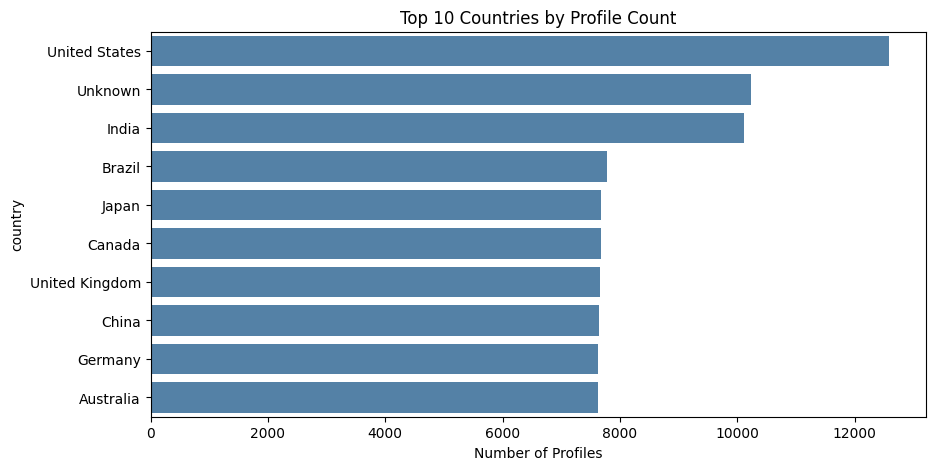

In [237]:
top_countries=data2['country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values,y=top_countries.index,color='steelblue')
plt.title('Top 10 Countries by Profile Count')
plt.xlabel('Number of Profiles')
plt.show()

### Suspicion Rate by Account Age

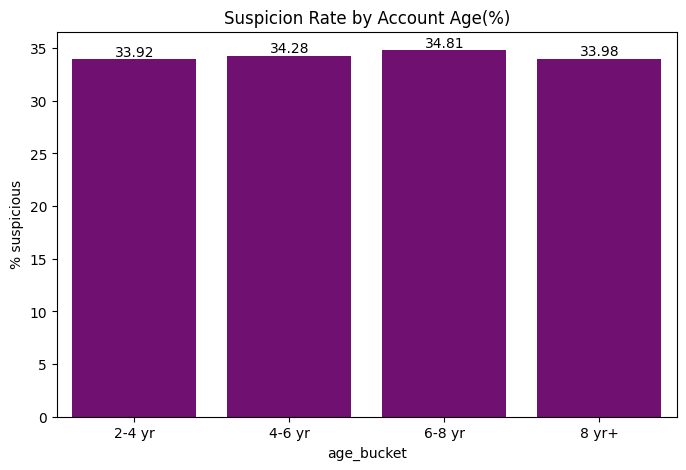

In [238]:
age_sus=data2.groupby('age_bucket')['is_suspicious'].mean()*100
plt.figure(figsize=(8,5))
ax=sns.barplot(x=age_sus.index,y=age_sus.values,color='purple')
plt.title('Suspicion Rate by Account Age(%)')
plt.ylabel('% suspicious')
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
plt.show()

### Suspicion Rate by Commit Frequency

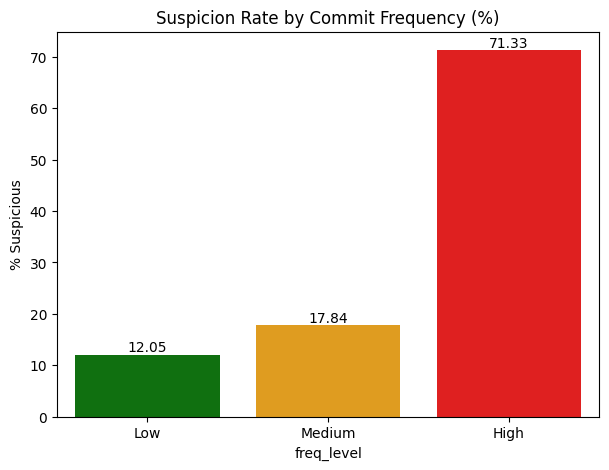

In [239]:
freq_sus=data2.groupby('freq_level')['is_suspicious'].mean().reindex(['Low','Medium','High'])*100
plt.figure(figsize=(7,5))
ax=sns.barplot(x=freq_sus.index,y=freq_sus.values,palette=['green','orange','red'])
plt.title('Suspicion Rate by Commit Frequency (%)')
plt.ylabel('% Suspicious')
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
plt.show()

### Correlation Heatmap

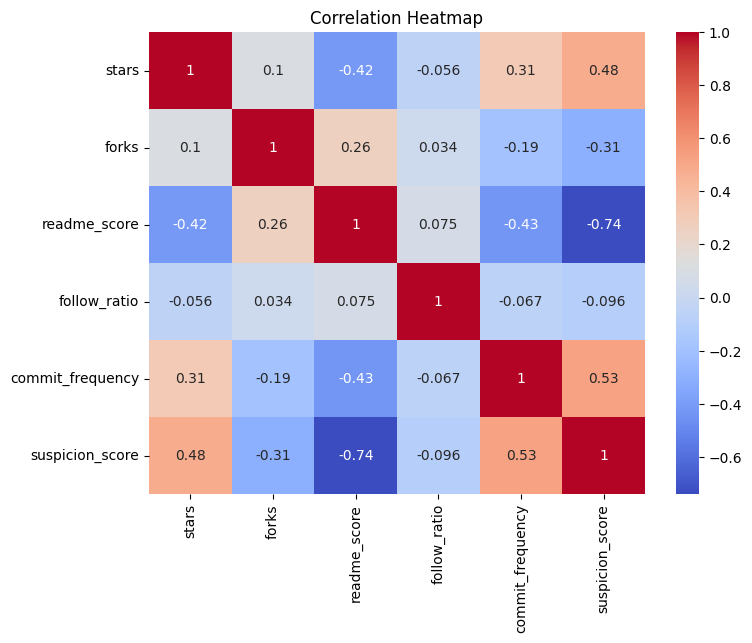

In [240]:
cols=['stars','forks','readme_score','follow_ratio','commit_frequency','suspicion_score']
plt.figure(figsize=(8,6))
sns.heatmap(data2[cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### README Score by Suspicion Tier

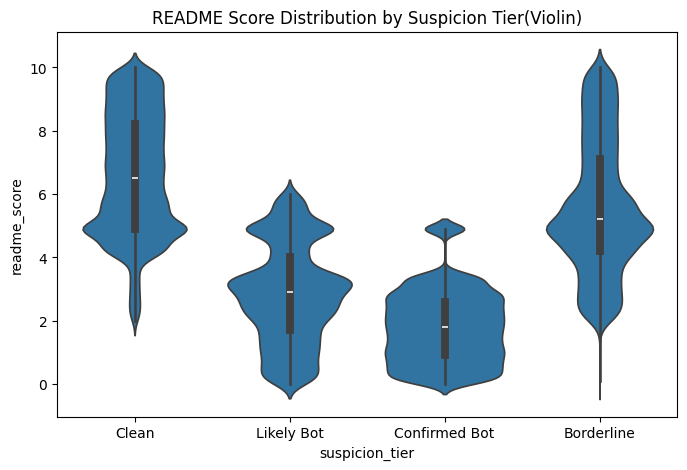

In [241]:
plt.figure(figsize=(8,5))
sns.violinplot(data=data2,x='suspicion_tier',y='readme_score')
plt.title('README Score Distribution by Suspicion Tier(Violin)')
plt.show()

### Follow Ratio Speed

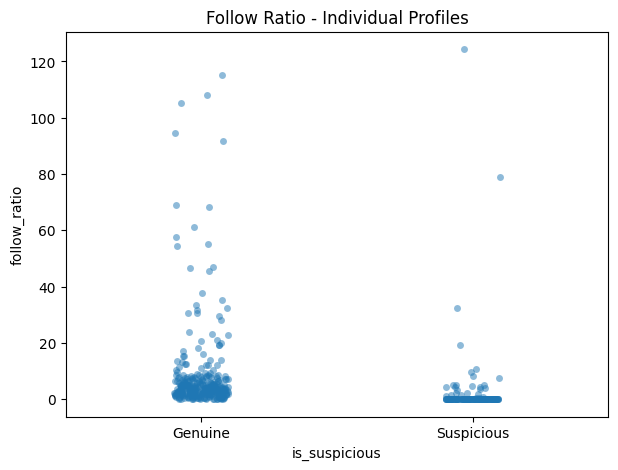

In [242]:
sample3=data2.sample(500,random_state=42)
plt.figure(figsize=(7,5))
sns.stripplot(data=sample3,x='is_suspicious',y='follow_ratio',alpha=0.5)
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Follow Ratio - Individual Profiles')
plt.show()

### README Score Spread

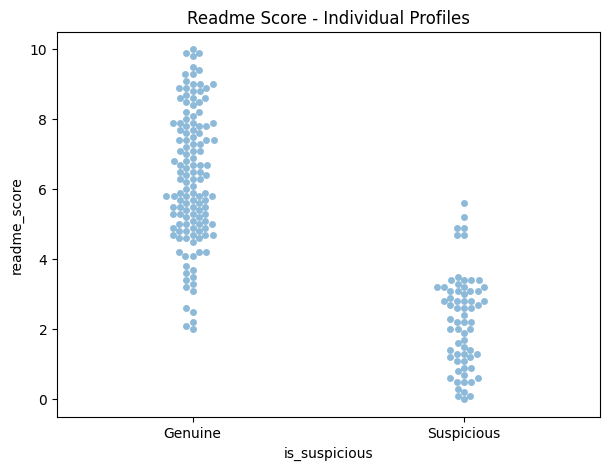

In [243]:
sample4=data2.sample(200,random_state=42)
plt.figure(figsize=(7,5))
sns.swarmplot(data=sample4,x='is_suspicious',y='readme_score',alpha=0.5)
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Readme Score - Individual Profiles')
plt.show()

### README Score vs Suspicion Score

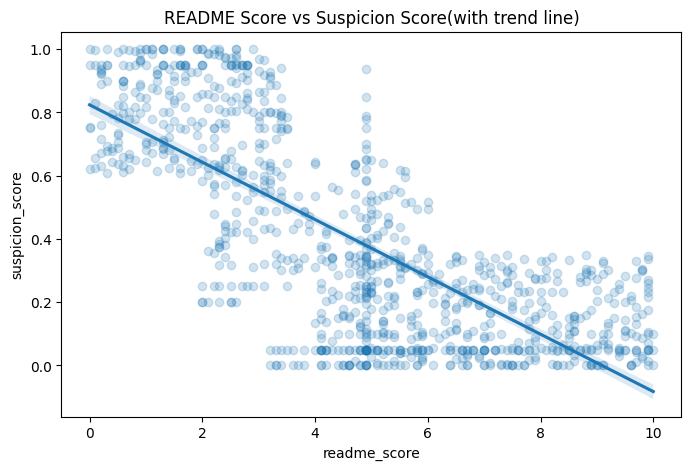

In [244]:
sample5=data2.sample(1000,random_state=42)
plt.figure(figsize=(8,5))
sns.regplot(data=sample5,x='readme_score',y='suspicion_score',scatter_kws={'alpha':0.2})
plt.title('README Score vs Suspicion Score(with trend line)')
plt.show()